In [ ]:
import json

# Load the Yelp dataset from the JSON file, considering only the first 'num_rows' rows
def load_yelp_dataset(file_path, num_rows):
    with open(file_path, 'r', encoding='utf-8') as file:
        data = [json.loads(next(file)) for _ in range(num_rows)]
    return data

# Function to filter out only restaurant reviews based on text
def filter_restaurant_reviews(data):
    restaurant_reviews = []
    for review in data:
        text = review.get('text', '').lower()
        if any(keyword in text for keyword in ['restaurant', 'dining', 'eatery', 'food', 'taste', 'cuisine', 'menu',
                                               'bistro', 'café', 'brasserie', 'tavern', 'gastropub', 'trattoria',
                                               'pizzeria', 'sushi bar', 'steakhouse', 'diner', 'pub', 'grill',
                                               'buffet', 'deli']):
            restaurant_reviews.append(review)
    return restaurant_reviews

# Path to the Yelp dataset JSON file
file_path = '/content/drive/MyDrive/NLP/yelp_academic_dataset_review.json'  # Update with the actual file path
num_rows_to_load = 2100000

# Load the first 'num_rows_to_load' rows from the Yelp dataset
yelp_data = load_yelp_dataset(file_path, num_rows_to_load)

# Filter out only restaurant reviews
restaurant_reviews = filter_restaurant_reviews(yelp_data)

# Check the number of restaurant reviews
print("Number of restaurant reviews in the first 2100,000 rows:", len(restaurant_reviews))


Number of restaurant reviews in the first 2100,000 rows: 1178433


In [ ]:
import pandas as pd

# Convert Yelp data to DataFrame
df = pd.DataFrame(restaurant_reviews)

# Display the first few rows of the DataFrame
df


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
4,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5.0,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16
...,...,...,...,...,...,...,...,...,...
1178428,RYStAlsDNAEa_08oXI0GLg,XCu35J2lp27WUwkNPWJoCA,Un-UDVOuv1co3TMmGaumxA,2.0,3,3,0,The view was lovely! The food we ordered was n...,2016-04-22 06:41:28
1178429,5jPhVhqYo_tOGrv6ZkG-hg,X0ThBT2nXkeEFzd7RSuy6Q,PRbf-L4kY5vOGLxwBwzdSg,4.0,3,1,2,I haven't tried their bingsoo yet. The only th...,2021-11-07 21:56:15
1178430,v-J_mh0jOtNJFcSa5DUyTA,day98v_BdvQcOMXFWcgDzg,bc6ZmnHMMwrJKEOBd1xCJg,2.0,2,0,0,Ordered via door dash and a few things were fo...,2021-12-08 04:14:02
1178431,rTDLisd1Tt5b_E7twzIV3g,uPr3t2M-OykA8M_oro7j1A,qnprJxrjwuEivitA8V2aEQ,5.0,11,1,9,Well looks like the hype is worth it and you'l...,2020-02-28 01:27:16


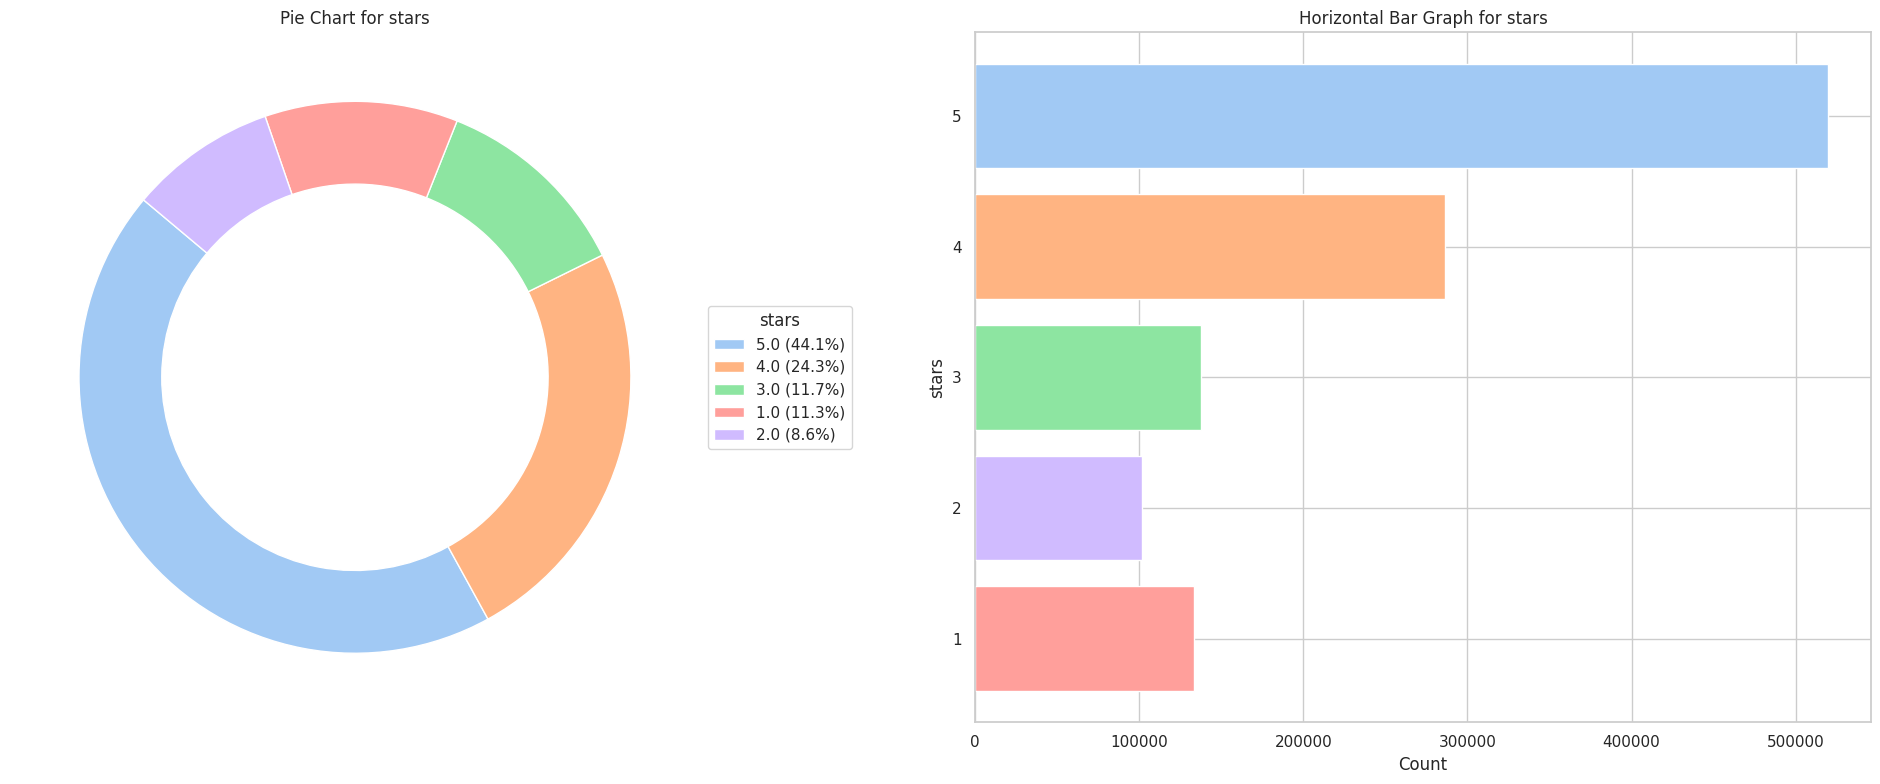

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_categorical_plots(variable):
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Pie Chart
    data = df[variable].value_counts()
    colors = sns.color_palette('pastel')[0:len(data)]
    wedges, _, _ = axes[0].pie(data, labels=None, autopct='', startangle=140, colors=colors, wedgeprops=dict(width=0.3))

    # Improve readability: Use legend for labels and percentages
    percentages = ['{:.1f}%'.format(val / sum(data) * 100) for val in data]
    axes[0].legend(wedges, [f'{label} ({percent})' for label, percent in zip(data.index, percentages)], title=variable, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    axes[0].set_title(f"Pie Chart for {variable}")

    # Horizontal Bar Graph
    axes[1].barh(y=data.index, width=data.values, color=colors)
    # ax.bar_label(ax.containers[0], fontsize=10);
    axes[1].set_xlabel("Count")
    axes[1].set_ylabel(variable)
    axes[1].set_title(f"Horizontal Bar Graph for {variable}")

    plt.tight_layout()
    plt.show()

create_categorical_plots("stars")

In [ ]:
# Identify common phrases or words used in the reviews
from wordcloud import WordCloud

# Generate word cloud for the most common words in the reviews
all_text = ' '.join(df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Reviews')
plt.axis('off')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Analyze the distribution of ratings
ratings = [review['stars'] for review in restaurant_reviews]

plt.figure(figsize=(8, 6))
plt.hist(ratings, bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks(range(1, 6))
plt.show()




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Analyze the structure of the dataset and explore its features
def explore_dataset(restaurant_reviews):
    # Print the keys (columns) in the dataset
    print("Keys in the dataset:", restaurant_reviews[0].keys())

    # Print the first review for reference
    print("\nSample Review:")
    print("Text:", restaurant_reviews[0].get('text'))
    print("Rating:", restaurant_reviews[0].get('stars'))

    # Analyze the distribution of ratings
    ratings = [review.get('stars') for review in restaurant_reviews]
    rating_counts = {rating: ratings.count(rating) for rating in set(ratings)}
    print("\nDistribution of Ratings:")
    for rating, count in sorted(rating_counts.items()):
        print(f"Rating {rating}: {count} reviews")

    # Analyze the length of reviews
    review_lengths = [len(review.get('text', '')) for review in restaurant_reviews]
    print("\nAverage Length of Reviews:", sum(review_lengths) / len(review_lengths))

# Explore the restaurant reviews dataset
explore_dataset(restaurant_reviews)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Remove standalone characters
def remove_standalone_characters(text):
    return re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

# Replace numbers with their alphabetical format
def replace_numbers(text):
    num_mapping = {
        '0': 'zero',
        '1': 'one',
        '2': 'two',
        '3': 'three',
        '4': 'four',
        '5': 'five',
        '6': 'six',
        '7': 'seven',
        '8': 'eight',
        '9': 'nine'
    }
    for num, word in num_mapping.items():
        text = text.replace(num, word)
    return text

# Remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

# Convert words like "icant" to "i cannot" and "ive" to "i have"
def expand_contractions(text):
    # Add more contractions if needed
    contractions_mapping = {
        "can't": "cannot",
        "won't": "will not",
        "n't": " not",
        "'ve": " have",
        "'re": " are",
        "'ll": " will",
        "'d": " would",
        "'m": " am"
    }
    for contraction, expanded_form in contractions_mapping.items():
        text = re.sub(contraction, expanded_form, text)
    return text

# Lemmatization
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized_tokens)

# Plot most common words
def plot_most_common_words(text, num_words=10):
    words = text.split()
    word_counter = Counter(words)
    most_common_words = word_counter.most_common(num_words)
    labels, counts = zip(*most_common_words)
    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    plt.title('Top 10 Most Common Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

# Preprocess text
def preprocess_text(text):
    text = convert_to_lowercase(text)
    text = remove_standalone_characters(text)
    text = replace_numbers(text)
    text = remove_stopwords(text)
    text = expand_contractions(text)
    text = lemmatize_text(text)
    return text

# Apply preprocessing to the text column
restaurant_reviews_text = [review['text'] for review in restaurant_reviews]
preprocessed_reviews_text = [preprocess_text(review_text) for review_text in restaurant_reviews_text]

# Plot most common words after preprocessing
all_reviews_text = ' '.join(preprocessed_reviews_text)
plot_most_common_words(all_reviews_text)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessed restaurant reviews
preprocessed_reviews = [review['text'] for review in restaurant_reviews]

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features as needed

# Fit and transform the preprocessed text data
tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_reviews)

# Check the shape of the TF-IDF matrix
print("Shape of TF-IDF matrix:", tfidf_matrix.shape)


In [ ]:
from sklearn.model_selection import train_test_split

# Extract star ratings from the original dataset
ratings = [review.get('stars') for review in restaurant_reviews]

# Split the TF-IDF matrix and star ratings into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, ratings, test_size=0.2, random_state=42)

# Check the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Length of y_train:", len(y_train))
print("Length of y_test:", len(y_test))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report as cls_report

# Initialize the Logistic Regression classifier
logistic_regression_classifier = LogisticRegression(max_iter=1000)  # You can adjust max_iter as needed

# Train the Logistic Regression classifier
logistic_regression_classifier.fit(X_train, y_train)

# Predict the sentiment for test set using Logistic Regression
y_pred_logistic_regression = logistic_regression_classifier.predict(X_test)

# Evaluate the performance of the Logistic Regression classifier
accuracy_logistic_regression = accuracy_score(y_test, y_pred_logistic_regression)
classification_report_logistic_regression = cls_report(y_test, y_pred_logistic_regression)

# Print the evaluation results for Logistic Regression
print("Logistic Regression Model Evaluation:")
print("Accuracy:", accuracy_logistic_regression)
print("\nClassification Report:")
print(classification_report_logistic_regression)




In [ ]:
# Assuming you have a new restaurant review in text format
new_review_text = "I had to wait so long for the food, i could easily get better service to some other food chain"

# Preprocess the new review text (using the same preprocessing steps as before)
# Replace 'preprocessed_text' with the preprocessed text of the new review
preprocessed_text = preprocess_text(new_review_text)

# Convert the preprocessed text into TF-IDF representation
# Replace 'tfidf_vectorizer' with the initialized TF-IDF vectorizer object
new_review_tfidf = tfidf_vectorizer.transform([preprocessed_text])

# Predict the sentiment of the new review using the trained Logistic Regression classifier
predicted_sentiment_logistic_regression = logistic_regression_classifier.predict(new_review_tfidf)

# Map the predicted sentiment to the corresponding label (e.g., positive, negative, neutral)
sentiment_labels = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}
predicted_sentiment_label_logistic_regression = sentiment_labels[predicted_sentiment_logistic_regression[0]]

# Print the predicted sentiment label
print("Predicted Sentiment (Logistic Regression):", predicted_sentiment_label_logistic_regression)


In [ ]:
!jupyter nbconvert --to html /content/NLP441.ipynb